In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df = df[df['job_title_short'] == 'Data Analyst'].copy()

In [6]:

df_exploded = df.explode('job_skills')

skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(10)

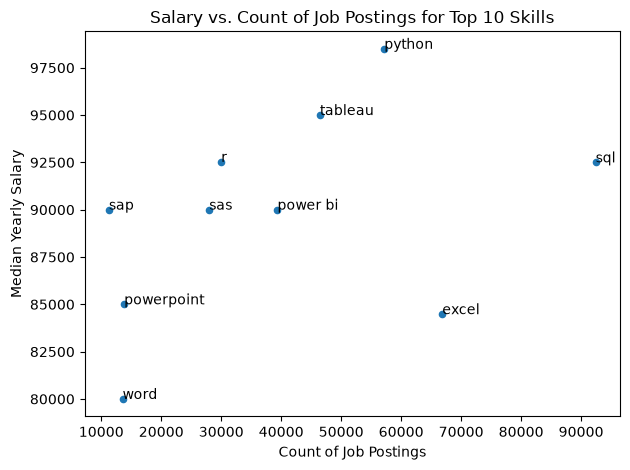

In [16]:
from pandas import PeriodIndex
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.tight_layout()

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)


plt.show()

In [20]:
df.iloc[489]

job_title_short                                               Data Analyst
job_title                    Data Analyst (HealthTech Associate Programme)
job_location                                                     Singapore
job_via                                                       via LinkedIn
job_schedule_type                                                Full-time
job_work_from_home                                                   False
search_location                                                  Singapore
job_posted_date                                        2023-01-17 13:25:21
job_no_degree_mention                                                False
job_health_insurance                                                 False
job_country                                                      Singapore
salary_rate                                                            NaN
salary_year_avg                                                        NaN
salary_hour_avg          